# Kierowanie pojazdem z wykorzystaniem sieci głębokich - CNN i ResNet

1. Przygotowanie zestawu danych
2. Trening sieci
3. Autonomiczna jazda w symulatorze!

## Pomysł

Wykorzystując obrazy z 3 kamer z symulatora, wykonaj predykcje kąta skrętu kierownicy.

![https://www.semanticscholar.org/paper/Learning-a-deep-neural-net-policy-for-end-to-end-of-Rausch-Hansen/19d98486f93d73a4d24811fb58bdd46e74faa808](https://ai2-s2-public.s3.amazonaws.com/figures/2017-08-08/19d98486f93d73a4d24811fb58bdd46e74faa808/4-Figure3-1.png)


In [4]:
!pip install livelossplot

from livelossplot import PlotLossesKeras
from distutils.version import LooseVersion

from sklearn.model_selection import train_test_split, KFold
from sklearn.utils import shuffle

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Flatten, Dense, Activation, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.models import Model, Sequential, model_from_json
from tensorflow.keras.callbacks import EarlyStopping

from tqdm import tqdm
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import cv2
import csv
import os
import warnings

In [2]:
# Check TensorFlow Version
assert LooseVersion(tf.__version__) >= LooseVersion('1.0'), 'Please use TensorFlow version 1.0 or newer.  You are using {}'.format(tf.__version__)
print('TensorFlow Version: {}'.format(tf.__version__))

# Check for a GPU
if not tf.test.gpu_device_name():
    warnings.warn('No GPU found. Please use a GPU to train your neural network.')
else:
    print('Default GPU Device: {}'.format(tf.test.gpu_device_name()))

TensorFlow Version: 2.19.0
Default GPU Device: /device:GPU:0


/tmp/ipykernel_1832/724577687.py:2: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  assert LooseVersion(tf.__version__) >= LooseVersion('1.0'), 'Please use TensorFlow version 1.0 or newer.  You are using {}'.format(tf.__version__)


# Dataset

Tutaj Możesz wrzucić swoje dane, które wygenerowujesz przejeżdzając kilka okrążeń

In [3]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving data.zip to data.zip
User uploaded file "data.zip" with length 82130644 bytes


In [5]:
import zipfile
import os

zip_path = "/content/data.zip"
extract_path = "/content/data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Rozpakowano data.zip!")

Rozpakowano data.zip!


In [6]:
!ls

data  data.zip	sample_data


In [9]:
import os

print(os.listdir('/content'))
print(os.listdir('/content/data'))

['.config', 'data', 'data.zip', 'sample_data']
['data']


Albo użyj już istniejących

In [ ]:
# !wget https://s3-eu-west-1.amazonaws.com/deepdrivepl/sdc-end2end-training-data.zip
# !rm -rf IMG driving_log.csv
# !unzip sdc-end2end-training-data.zip


#!wget https://s3-eu-west-1.amazonaws.com/deepdrivepl/datasets/UdacitySim/sdc-end2end-train-set2.zip
#!rm -rf IMG driving_log.csv
#!unzip sdc-end2end-train-set2.zip

--2019-04-19 04:38:31--  https://s3-eu-west-1.amazonaws.com/deepdrivepl/datasets/UdacitySim/sdc-end2end-train-set2.zip
Resolving s3-eu-west-1.amazonaws.com (s3-eu-west-1.amazonaws.com)... 52.218.104.74
Connecting to s3-eu-west-1.amazonaws.com (s3-eu-west-1.amazonaws.com)|52.218.104.74|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 137811977 (131M) [application/zip]
Saving to: ‘sdc-end2end-train-set2.zip’

sdc-end2end-train-s 100%[===================>] 131.43M  30.5MB/s    in 4.9s    

2019-04-19 04:38:36 (26.7 MB/s) - ‘sdc-end2end-train-set2.zip’ saved [137811977/137811977]

Archive:  sdc-end2end-train-set2.zip
   creating: IMG/
  inflating: IMG/center_2019_04_19_06_04_38_668.jpg  
  inflating: IMG/right_2019_04_19_06_04_38_944.jpg  
  inflating: IMG/left_2019_04_19_06_04_39_166.jpg  
  inflating: IMG/left_2019_04_19_06_04_39_706.jpg  
  inflating: IMG/right_2019_04_19_06_04_40_828.jpg  
  inflating: IMG/center_2019_04_19_06_04_41_335.jpg  
  inflating: IMG/l

# Jak wygląda przejazd widziany z kamerki?



In [10]:
!ffmpeg -pattern_type glob -i '/content/data/data/IMG/center*.jpg' -c:v libx264 data.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [11]:
! ls -lah data.mp4

-rw-r--r-- 1 root root 14M Mar 19 17:27 data.mp4


In [2]:
import io
import base64
from IPython.display import HTML

video = io.open('data.mp4', 'r+b').read()
encoded = base64.b64encode(video)
HTML(data='''<video alt="test" controls>
                <source src="data:video/mp4;base64,{0}" type="video/mp4" />
             </video>'''.format(encoded.decode('ascii')))

FileNotFoundError: [Errno 2] No such file or directory: 'data.mp4'

## Data preparation

In [6]:
import os
import csv

def load_data(training_csv, images_dir):
    dataset = []

    with open(training_csv, 'r') as csvfile:
        data = list(csv.reader(csvfile, delimiter=','))

        for center_name, left_name, right_name, steering, throttle, brake, speed in data:
            center_name = os.path.join(images_dir, os.path.basename(center_name.strip().replace('\\', '/')))
            left_name = os.path.join(images_dir, os.path.basename(left_name.strip().replace('\\', '/')))
            right_name = os.path.join(images_dir, os.path.basename(right_name.strip().replace('\\', '/')))

            steering = float(steering)
            throttle = float(throttle)
            brake = float(brake)
            speed = float(speed)

            dataset.append([center_name, left_name, right_name, steering, throttle, brake, speed])

    return dataset

dataset = load_data('/content/data/data/driving_log.csv', '/content/data/data/IMG')

print('Lines in dataset:', len(dataset))
print('First line:', dataset[0])
print('Center exists:', os.path.exists(dataset[0][0]))
print('Left exists:', os.path.exists(dataset[0][1]))
print('Right exists:', os.path.exists(dataset[0][2]))

Lines in dataset: 1750
First line: ['/content/data/data/IMG/center_2026_03_18_21_02_06_373.jpg', '/content/data/data/IMG/left_2026_03_18_21_02_06_373.jpg', '/content/data/data/IMG/right_2026_03_18_21_02_06_373.jpg', 0.0, 0.0, 0.0, 7.964645e-05]
Center exists: True
Left exists: True
Right exists: True


## Jak wyglądają nasze dane?

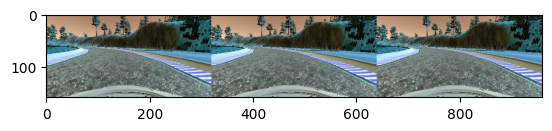

In [20]:
center_img = cv2.imread(dataset[0][0])
left_img = cv2.imread(dataset[0][0])
right_img = cv2.imread(dataset[0][0])

plt.imshow(np.concatenate([left_img, center_img, right_img], axis=1));

Obrazy z lewej, środkowej i prawej kamery są takie same, więc możemy użyć tylko środkowego.

Przekonwertujemy obraz z formatu BGR (domyślny dla OpenCV) na format RGB (domyślny dla matplotlib) za pomocą funkcji `cv2.cvtColor()` i `cv2.COLOR_RGB2BGR`.

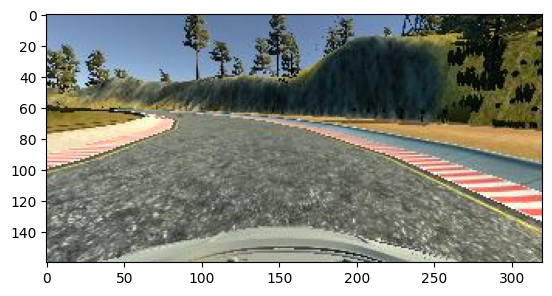

In [21]:
plt.imshow(cv2.cvtColor(center_img,cv2.COLOR_RGB2BGR));

## Przygotowanie X i y

Ponieważ używamy tylko środkowego obrazu, zignorujemy pozostałe i zostawimy tylko pierwszą kolumnę jako nasze dane wejściowe X.

Chcemy przewidzieć kąt skrętu, więc interesuje nas kąt kierownicy (4. kolumna - kolumna z id 3). Użyjemy jej jako wektora *y*.

In [7]:
X = [_[0] for _ in dataset]
y = [_[3] for _ in dataset]

In [8]:
print('len(X):', len(X))
print('len(y)', len(y))
print('x:', X[0])
print('y:', y[0])

len(X): 1750
len(y) 1750
x: /content/data/data/IMG/center_2026_03_18_21_02_06_373.jpg
y: 0.0


## Train/Val split (ratio 9:1)

In [13]:
X_train_path, X_val_path, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

print("Lengths:")
print('X train:', len(X_train_path))
print('y_train:', len(y_train))

print('X val:', len(X_val_path))
print('y val:', len(y_val))

print('\nExamples:')
print('Train:', X_train_path[0], y_train[0])
print('Val:', X_val_path[0], y_val[0])

Lengths:
X train: 1575
y_train: 1575
X val: 175
y val: 175

Examples:
Train: /content/data/data/IMG/center_2026_03_18_21_03_16_551.jpg 0.0
Val: /content/data/data/IMG/center_2026_03_18_21_04_15_125.jpg -0.1498572


## Histogram

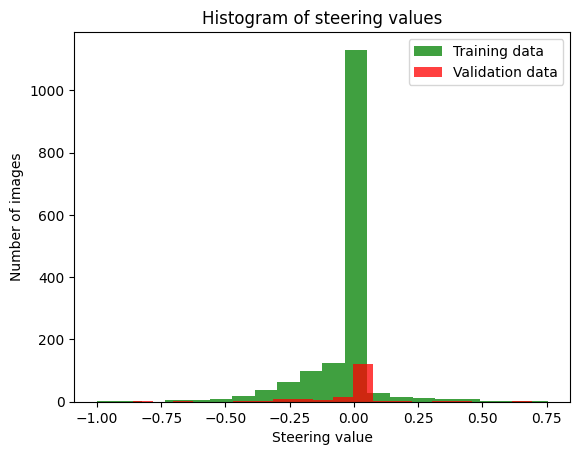

In [25]:
# the histogram of the steering data - train and val
n, bins, patches = plt.hist(y_train, 20, facecolor='green', alpha=0.75,label=['Training data'])
n, bins, patches = plt.hist(y_val, 20, facecolor='red', alpha=0.75, stacked=False,label=['Validation data'])
plt.xlabel('Steering value')
plt.ylabel('Number of images')
plt.title('Histogram of steering values')
plt.legend()
plt.show();


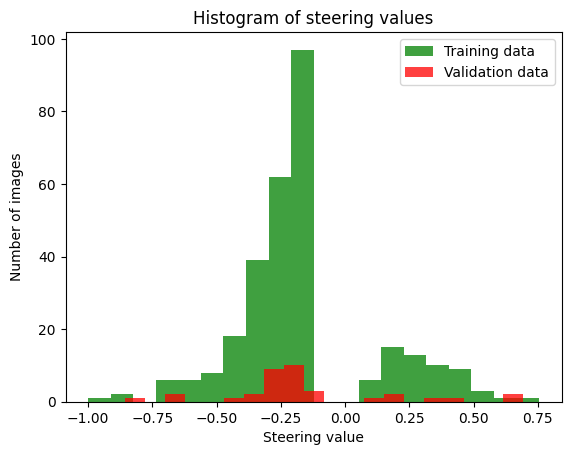

In [26]:
X_train_path, y_train = zip(*[_ for _ in zip(X_train_path, y_train) if _[1]<-0.125 or _[1]>0.125])
X_val_path, y_val = zip(*[_ for _ in zip(X_val_path, y_val) if _[1]<-0.125 or _[1]>0.125])
n, bins, patches = plt.hist(y_train, 20, facecolor='green', alpha=0.75,label=['Training data'])
n, bins, patches = plt.hist(y_val, 20, facecolor='red', alpha=0.75, stacked=False,label=['Validation data'])
plt.xlabel('Steering value')
plt.ylabel('Number of images')
plt.title('Histogram of steering values')
plt.legend()
plt.show();


# Image preprocessing

In [9]:
def process_image(image):
  image=image[10:130:4,::2,:]
  image=np.mean(image,axis=2)
  image=(image-image.min())/255.0-0.5
  image=image.reshape(image.shape[0],image.shape[1],1)
  return image

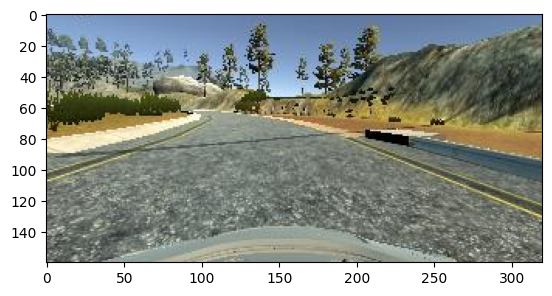

In [29]:
img = cv2.imread(X_train_path[0])
plt.imshow(cv2.cvtColor(img,cv2.COLOR_RGB2BGR));

Processed image shape: (30, 160)


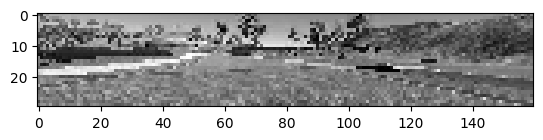

In [30]:
processed = process_image(img)[:,:,0]
print('Processed image shape:',processed.shape)
plt.imshow(processed, cmap='gray');

## Prepare inputs

Preprocess all of the images

In [31]:
X_train = [process_image(cv2.imread(_)) for _ in X_train_path]
X_val = [process_image(cv2.imread(_)) for _ in X_val_path]
print(len(X_train), X_train[0].shape)
print(len(X_val), X_val[0].shape)

297 (30, 160, 1)
35 (30, 160, 1)


In [32]:
X_train=np.array(X_train)
X_val=np.array(X_val)
y_train=np.array(y_train)
y_val=np.array(y_val)

In [33]:
print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)

(297, 30, 160, 1)
(35, 30, 160, 1)
(297,)
(35,)


# Model
![Nvidia end to end](https://devblogs.nvidia.com/wp-content/uploads/2016/08/cnn-architecture-624x890.png)

In [12]:
def nvidiaModel(input_shape):
    model = Sequential([
        Conv2D(24, (5, 5), strides=(2, 2), activation='relu', input_shape=input_shape),
        Conv2D(36, (5, 5), strides=(2, 2), activation='relu'),
        Conv2D(48, (5, 5), strides=(2, 2), activation='relu'),
        Conv2D(64, (3, 3), activation='relu'),
        Conv2D(64, (3, 3), activation='relu'),
        Flatten(),
        Dense(100, activation='relu'),
        Dropout(0.3),
        Dense(50, activation='relu'),
        Dense(10, activation='relu'),
        Dense(1)
    ])
    return model

def simpleModel(input_shape):
    model = Sequential([
        Conv2D(16, (3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(32, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    return model



# create the model
model = simpleModel((30, 160, 1))

# print summary
model.summary()
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 158, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 79, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 77, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 38, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 36, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 18, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 172,929 (675.50 KB)

 Trainable params: 172,929 (675.50 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
X_train = np.array([
    process_image(cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB))
    for path in X_train_path
])

X_val = np.array([
    process_image(cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB))
    for path in X_val_path
])

y_train = np.array(y_train, dtype=np.float32)
y_val = np.array(y_val, dtype=np.float32)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

X_train: (1575, 30, 160, 1)
X_val: (175, 30, 160, 1)


# Training

In [35]:
from sklearn.model_selection import KFold

np.random.seed(42)
tf.random.set_seed(42)

# przygotowanie pełnego zbioru do CV
X_all = np.array([process_image(cv2.imread(path)) for path in X])
y_all = np.array(y, dtype=np.float32)

print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)

fold_no = 1
fold_scores = []
best_val_loss = np.inf
best_weights = None

for train_idx, val_idx in kfold.split(X_all):
    print(f"\n========== FOLD {fold_no} ==========")

    X_train_fold, X_val_fold = X_all[train_idx], X_all[val_idx]
    y_train_fold, y_val_fold = y_all[train_idx], y_all[val_idx]

    model = simpleModel(X_all[0].shape)
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=30,
        batch_size=128,
        shuffle=True,
        verbose=1,
        callbacks=[early_stop]
    )

    val_loss, val_mae = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"Fold {fold_no} -> val_loss: {val_loss:.6f}, val_mae: {val_mae:.6f}")

    fold_scores.append((val_loss, val_mae))

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = model.get_weights()

    fold_no += 1

print("\n========== PODSUMOWANIE CV ==========")
for i, (loss, mae) in enumerate(fold_scores, start=1):
    print(f"Fold {i}: val_loss={loss:.6f}, val_mae={mae:.6f}")

mean_loss = np.mean([score[0] for score in fold_scores])
mean_mae = np.mean([score[1] for score in fold_scores])

print(f"\nŚredni val_loss z 5 foldów: {mean_loss:.6f}")
print(f"Średni val_mae  z 5 foldów: {mean_mae:.6f}")
print(f"Najlepszy val_loss: {best_val_loss:.6f}")

# odtworzenie najlepszego modelu
final_model = simpleModel(X_all[0].shape)
final_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)
final_model.set_weights(best_weights)

model = final_model

X_all shape: (1750, 30, 160, 1)
y_all shape: (1750,)

========== FOLD 1 ==========
Epoch 1/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 13s 613ms/step - loss: 0.0220 - mae: 0.0906 - val_loss: 0.0168 - val_mae: 0.0731
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0196 - mae: 0.0803 - val_loss: 0.0166 - val_mae: 0.0731
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0186 - mae: 0.0806 - val_loss: 0.0160 - val_mae: 0.0711
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0177 - mae: 0.0770 - val_loss: 0.0155 - val_mae: 0.0719
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0173 - mae: 0.0760 - val_loss: 0.0149 - val_mae: 0.0701
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0165 - mae: 0.0766 - val_loss: 0.0149 - val_mae: 0.0775
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0156 - mae: 0.0749 - val_loss: 0.0146 - val_mae: 0.0783
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0144 - mae: 0.0733 - val_loss: 0.01

## Save model

In [39]:
model.save_weights("model.weights.h5")

## Download model

In [40]:
from google.colab import files
files.download("model.weights.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Data augmentation

In [ ]:
def deprocess(img):
  return ((img+0.5)*255.0).astype(np.uint8)

In [15]:
def random_flip(image, steering_angle):
    if np.random.rand() < 0.5:
        image = cv2.flip(image, 1)
        steering_angle = -steering_angle
    return image, steering_angle

def random_translate(image, steering_angle):
    trans_x = 100 * (np.random.rand() - 0.5)
    trans_y = 20 * (np.random.rand() - 0.5)

    steering_angle += trans_x / 100

    trans_m = np.float32([[1, 0, trans_x], [0, 1, trans_y]])
    h, w = image.shape[:2]
    image = cv2.warpAffine(image, trans_m, (w, h))

    return image, steering_angle

def augment(image, steering_angle):
    image, steering_angle = random_translate(image, steering_angle)
    image, steering_angle = random_flip(image, steering_angle)
    return image, steering_angle

0.0


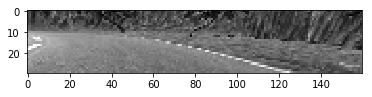

In [ ]:
_id = 3
img = X_train[_id,:,:,0]
angle = y_train[_id]
plt.imshow(deprocess(img), cmap='gray');
print(angle)

0.2


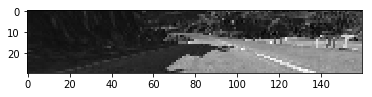

In [ ]:
_img, _angle = random_flip(img,angle)
print(_angle)
plt.imshow(deprocess(_img), cmap='gray');

-0.3934428315598608


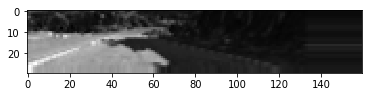

In [ ]:
_img, _angle = random_translate(img,angle)
print(_angle)
plt.imshow(deprocess(_img), cmap='gray');

## Batch generator

In [16]:
def gen_batch_function(X, y, batch_size):
    while True:
        X_shuffled, y_shuffled = shuffle(X, y)

        batch_X = []
        batch_y = []

        for _X, _y in zip(X_shuffled, y_shuffled):
            aX, ay = augment(_X, _y)

            batch_X.append(aX)
            batch_y.append(ay)

            if len(batch_X) >= batch_size:
                yield np.array(batch_X), np.array(batch_y, dtype=np.float32)
                batch_X = []
                batch_y = []

In [17]:
model = simpleModel(X_train[0].shape)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.fit(
    gen_batch_function(X_train, y_train, 128),
    steps_per_epoch=1 + len(X_train)//128,
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

Epoch 1/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 496ms/step - loss: 0.0614 - mae: 0.1961 - val_loss: 0.0295 - val_mae: 0.1304
Epoch 2/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 363ms/step - loss: 0.0388 - mae: 0.1463 - val_loss: 0.0235 - val_mae: 0.0955
Epoch 3/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 387ms/step - loss: 0.0297 - mae: 0.1240 - val_loss: 0.0247 - val_mae: 0.1043
Epoch 4/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 418ms/step - loss: 0.0272 - mae: 0.1155 - val_loss: 0.0248 - val_mae: 0.1038
Epoch 5/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 365ms/step - loss: 0.0271 - mae: 0.1146 - val_loss: 0.0232 - val_mae: 0.0938
Epoch 6/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 473ms/step - loss: 0.0268 - mae: 0.1101 - val_loss: 0.0259 - val_mae: 0.1028
Epoch 7/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 379ms/step - loss: 0.0250 - mae: 0.1038 - val_loss: 0.0239 - val_mae: 0.1039
Epoch 8/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 417ms/step - loss: 0.0237 - mae: 0.0997 - val_loss: 0.0225 - val_mae: 0.0862
Epoch 9/30
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 400ms/step - lo

In [ ]:
model = simpleModel(X_train[0].shape)

model.summary()
model.compile("adam", "mse")

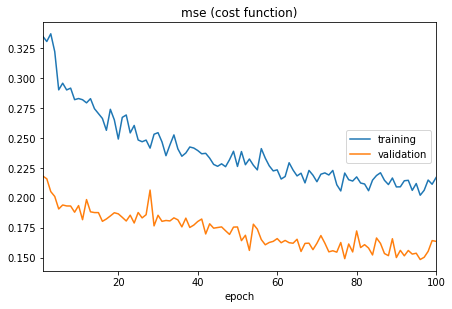

mse (cost function):
training   (min:    0.202, max:    0.337, cur:    0.217)
validation (min:    0.148, max:    0.218, cur:    0.164)


In [ ]:
batch_size = 512
model.fit_generator(gen_batch_function(X_train, y_train, batch_size),
                    steps_per_epoch=1+len(X_train)//batch_size, epochs=100,
                    callbacks=[PlotLossesKeras()],
                    validation_data=[X_val, y_val],
                    validation_steps=len(X_val)//batch_size)

## Save new model

In [18]:
model.save_weights("model_aug.weights.h5")

In [ ]:
# save weights
model.save('model_aug.h5')
print("Saved model_aug.h5")

Saved model_aug.h5


## Download new model

In [19]:
from google.colab import files
files.download("model_aug.weights.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download('model_aug.h5')

# Zadanie 1: Implementacja i trenowanie modelu CNN - dodać: cross-validation i weryfikacja przejazdu korzystając ze skryptu drive.py

# Zadanie 2: Implementacja i trenowanie modelu CNN + augumentacja danych i weryfikacja przejazdu korzystając ze skryptu drive.py

# Zadanie 3: Implementacja i trenowanie modelu ResNet/VGG oraz Inception i weryfikacja przejazdu korzystając ze skryptu drive.py (bez augumentacji) - zainspiruj sie kodem z Konwersatorium oraz poniżej

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, Add, Input, MaxPooling2D, Flatten, Dense, Dropout

def resnet_block(x, filters, kernel_size=(3, 3), strides=(1, 1)):
    """
    A residual block with two Conv2D layers and a skip connection.
    """
    # First convolutional layer
    conv = Conv2D(filters, kernel_size, strides=strides, padding='same')(x)
    conv = BatchNormalization()(conv)
    conv = Activation('relu')(conv)

    # Second convolutional layer
    conv = Conv2D(filters, kernel_size, padding='same')(conv)
    conv = BatchNormalization()(conv)

    # Skip connection
    if x.shape[-1] != filters or strides != (1, 1):
        shortcut = Conv2D(filters, (1, 1), strides=strides, padding='same')(x)
        shortcut = BatchNormalization()(shortcut)
    else:
        shortcut = x

    # Add skip connection
    conv = Add()([shortcut, conv])
    conv = Activation('relu')(conv)
    return conv

def resnet_model(input_shape):
    """
    ResNet-inspired model for regression with input_shape.
    """
    inputs = Input(shape=input_shape)

    # Initial convolutional layer
    x = Conv2D(32, (7, 7), strides=(2, 2), padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(3, 3), strides=(2, 2), padding='same')(x)

    # Residual blocks
    x = resnet_block(x, filters=32)
    x = resnet_block(x, filters=32)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.3)(x)

    x = resnet_block(x, filters=64, strides=(2, 2))
    x = resnet_block(x, filters=64)
    x = Dropout(0.3)(x)

    x = resnet_block(x, filters=128, strides=(2, 2))
    x = resnet_block(x, filters=128)
    x = Dropout(0.3)(x)

    # Flatten and dense layers for regression
    x = Flatten()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(1)(x)

    # Create model
    model = Model(inputs=inputs, outputs=x)
    return model

# Print image shapes
print("Image shape before processing:", img.shape)
print("Image shape after processing:", process_image(img).shape)

# Create the ResNet model
model = resnet_model(process_image(img).shape)

# Print model summary
model.summary()

# Compile the model
model.compile(optimizer="adam", loss="mse")

# Zadanie 4: Implementacja i trenowanie modelu ResNet/VGG/Inception i weryfikacja przejazdu korzystając ze skryptu drive.py (z augumentacja)